<style>
  body {
    margin: 0;
    padding: 0;
    font-family: Arial, sans-serif;
  }

  /* Linha das logos usando table layout */
  .cover-header {
    display: table;
    width: 100%;
    margin-top: 20px;
    table-layout: fixed;
  }

  .cover-header .left{
    display: table-cell;
    width: 20%;
    vertical-align: middle;
    text-align: center;
  }
  .cover-header .right {
    display: table-cell;
    width: 30%;
    vertical-align: middle;
    text-align: center;
  }

  .cover-header .center {
    display: table-cell;
    width: 50%;
    text-align: center;
    vertical-align: middle;
  }

  .cover-header img {
    max-height: 55px;
    width: auto;
    display: inline-block;
  }

  /* Texto institucional embaixo das logos */
  .cover-center {
    text-align: center;
    margin-top: 20px;
    vertical-align: middle;
  }

  .cover-center p {
    text-align: center;
    vertical-align: middle;
    margin: 0;
    font-weight: 700;
    line-height: 1.4;
    font-size: 16px;
  }

  /* Título e autor */
  .cover-title {
    margin-top: 120px;
    text-align: center;
  }

  .cover-title h1 {
    font-size: 28px;
    margin-bottom: 60px;
  }

  .cover-title .author {
    font-size: 18px;
    margin-top: 160px; /* nome bem mais abaixo */
  }

  /* Rodapé fixo */
  .cover-footer {
    position: absolute;
    bottom: 30px;
    left: 0;
    width: 100%;
    text-align: center;
    font-size: 14px;
  }

  .cover-footer {
  position: absolute;
  bottom: 30px;
  left: 0;
  width: 100%;
  text-align: center;
  font-size: 14px;
}

</style>

<div class="cover-header">
  <div class="left">
    <img src="Imagens/logo_virtus2.png" alt="Logo VIRTUS">
  </div>
  <div class = "center"></div>
  <div class="right">
    <img src="Imagens/logo_ufcg.png" alt="Logo UFCG">
  </div>
</div>

<div class="cover-center">
  <p>
    UNIVERSIDADE FEDERAL DE CAMPINA GRANDE<br>
    CENTRO DE CIÊNCIAS E TECNOLOGIA<br>
    CENTRO DE ENGENHARIA ELÉTRICA E INFORMÁTICA<br>
    CENTRO DE COMPETÊNCIAS EMBRAPII VIRTUS-CC
  </p>
</div>

<div class="cover-title">
  <h1>Transceptores Digitais</h1>
  <p class="author">Jezrael Pereira Filgueiras</p>
</div>

<div class="cover-footer">
  Campina Grande, 12 de abril de 2026
</div>

<div style="page-break-after: always;"></div>

# 1 Introdução

# 2 Desenvolvimento

## 2.1 Transmissor 

In [31]:
import numpy as np
import matplotlib.pyplot as plt

from optic.comm.sources import bitSource
from optic.comm.modulation import modulateGray
from optic.comm.metrics import bert, fastBERcalc
from optic.dsp.core import firFilter, pulseShape, upsample, pnorm, anorm, decimate
from optic.utils import parameters, dBm2W
from optic.models.devices import dac, adc
from optic.models.channels import awgn
from optic.plot import eyediagram, plotColoredConst, pconst
from scipy.special import erfc

In [32]:
SpS = 8
M = [2, 4, 8, 16]  
Rs = 10e8  
Fs = SpS * Rs

paramBits = parameters()
paramBits.nBits = 240000
paramBits.mode = 'random' 
paramBits.seed = 42

paramPulse = parameters()
paramPulse.pulseType = 'nrz'  
paramPulse.SpS = SpS

paramDac = parameters()
paramDac.inFs = Fs
paramDac.outFs = 8 * Fs
paramDac.nBits = 12
paramDac.ENOB = 12
paramDac.Vpp = 2

paramAWGN = parameters()
paramAWGN.Fs = Fs
paramAWGN.B = Rs
paramAWGN.complexNoise = False
paramAWGN.seed = 42

paramAdc = parameters()
paramAdc.inFs = 8 * Fs
paramAdc.outFs = Fs
paramAdc.nBits = 12
paramAdc.ENOB = 12

paramDec = parameters()
paramDec.SpSin = SpS
paramDec.SpSout = 1


In [33]:
bits = bitSource(paramBits)
pulse = pulseShape(paramPulse)
signalsTx = []
symbsTx = []
for i in range(len(M)):  
    symbols = modulateGray(bits, M[i], constType = 'pam')
    symbsTx.append(symbols)
    sigTx = upsample(symbols, SpS)
    sigTx = firFilter(pulse, sigTx)
    sigTx = dac(sigTx, paramDac)
    signalsTx.append(sigTx)

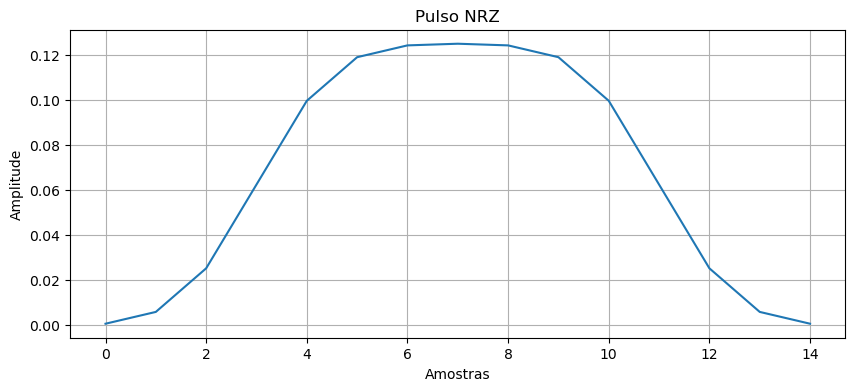

In [34]:
# Plot do pulso utilizado
plt.figure(figsize=(10, 4))
plt.plot(pulse)
plt.xlabel('Amostras')
plt.ylabel('Amplitude')
plt.title('Pulso NRZ')
plt.grid(True)
plt.show()

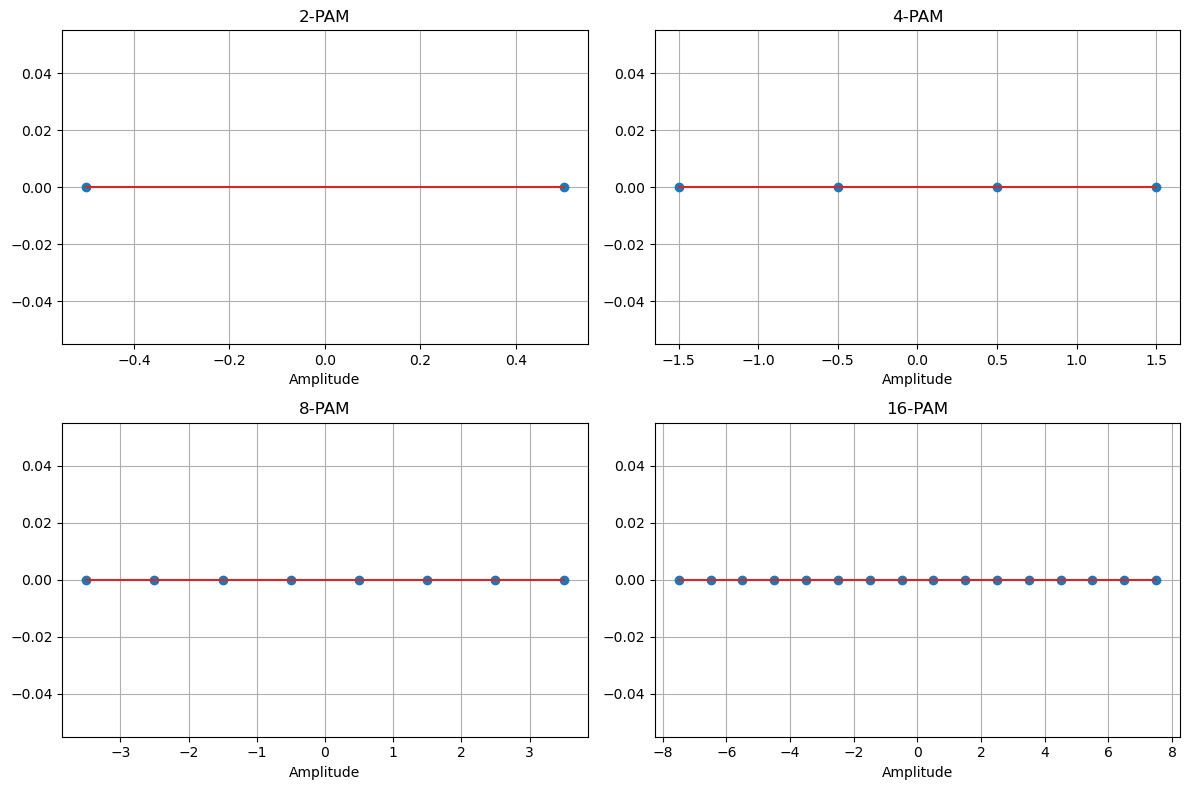

In [35]:
# Plot das constelações 2-PAM, 4-PAM, 8-PAM e 16-PAM
plt.figure(figsize=(12, 8))
for i in range(len(M)):
    plt.subplot(2, 2, i + 1)
    constellation = np.arange(M[i]) - (M[i] - 1) / 2
    plt.stem(constellation, np.zeros_like(constellation))
    plt.xlabel('Amplitude')
    plt.title(f'{M[i]}-PAM')
    plt.grid(True)

plt.tight_layout()
plt.show()

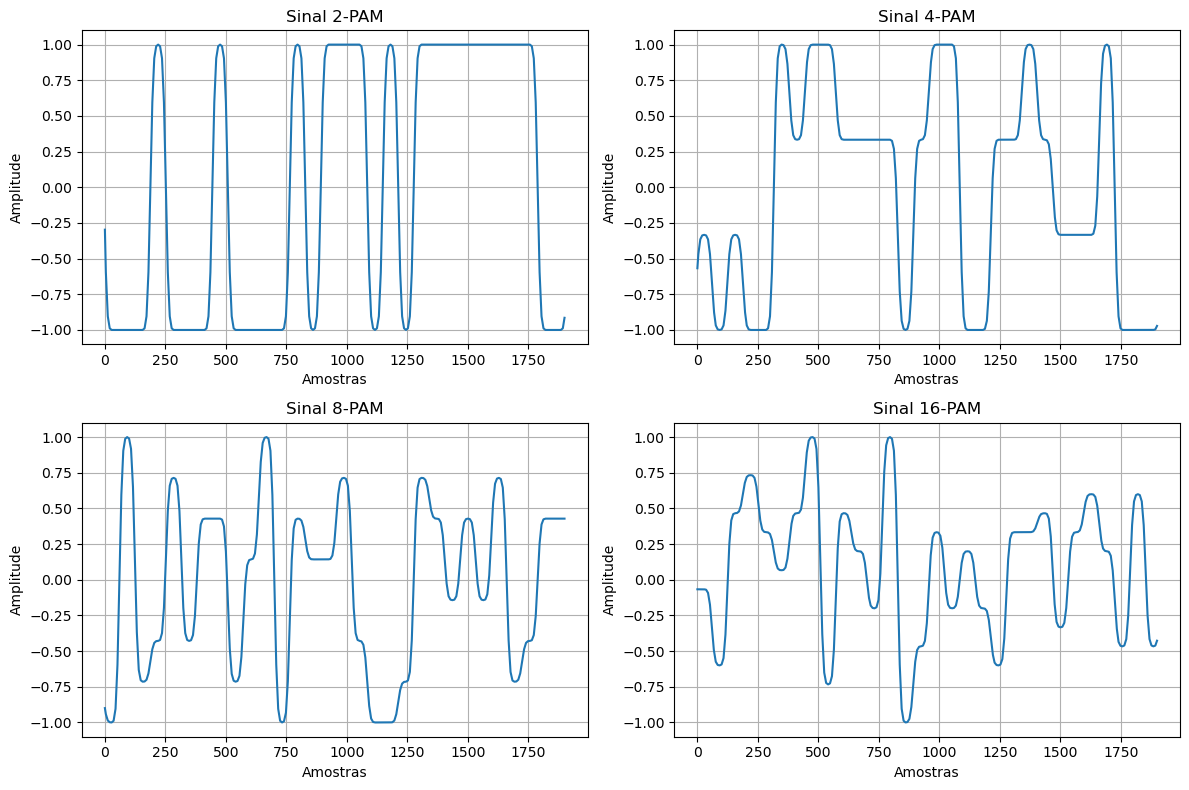

In [36]:
# Plot dos sinais transmitidos
plt.figure(figsize=(12, 8))
for i in range(len(M)):
    plt.subplot(2, 2, i + 1)
    plt.plot(signalsTx[i][100:2000])
    plt.xlabel('Amostras')
    plt.ylabel('Amplitude')
    plt.title(f'Sinal {M[i]}-PAM')
    plt.grid(True)
plt.tight_layout()
plt.show()

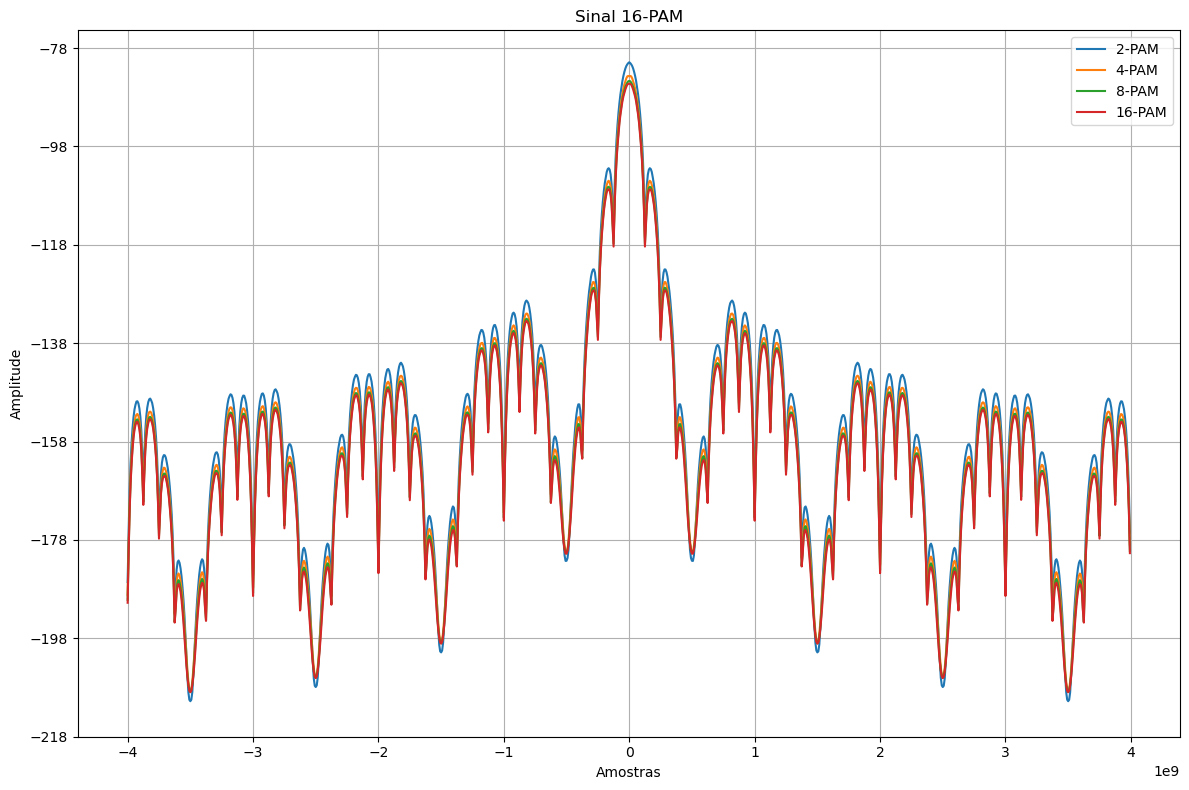

In [37]:
plt.figure(figsize=(12, 8))
for i in range(len(M)):
    plt.psd(signalsTx[i], NFFT = 1024, Fs = Fs, label = f'{M[i]}-PAM', sides = 'twosided')
    plt.xlabel('Amostras')
    plt.ylabel('Amplitude')
    plt.title(f'Sinal {M[i]}-PAM')
    plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 2.2 Canal

## 2.3 Receptor

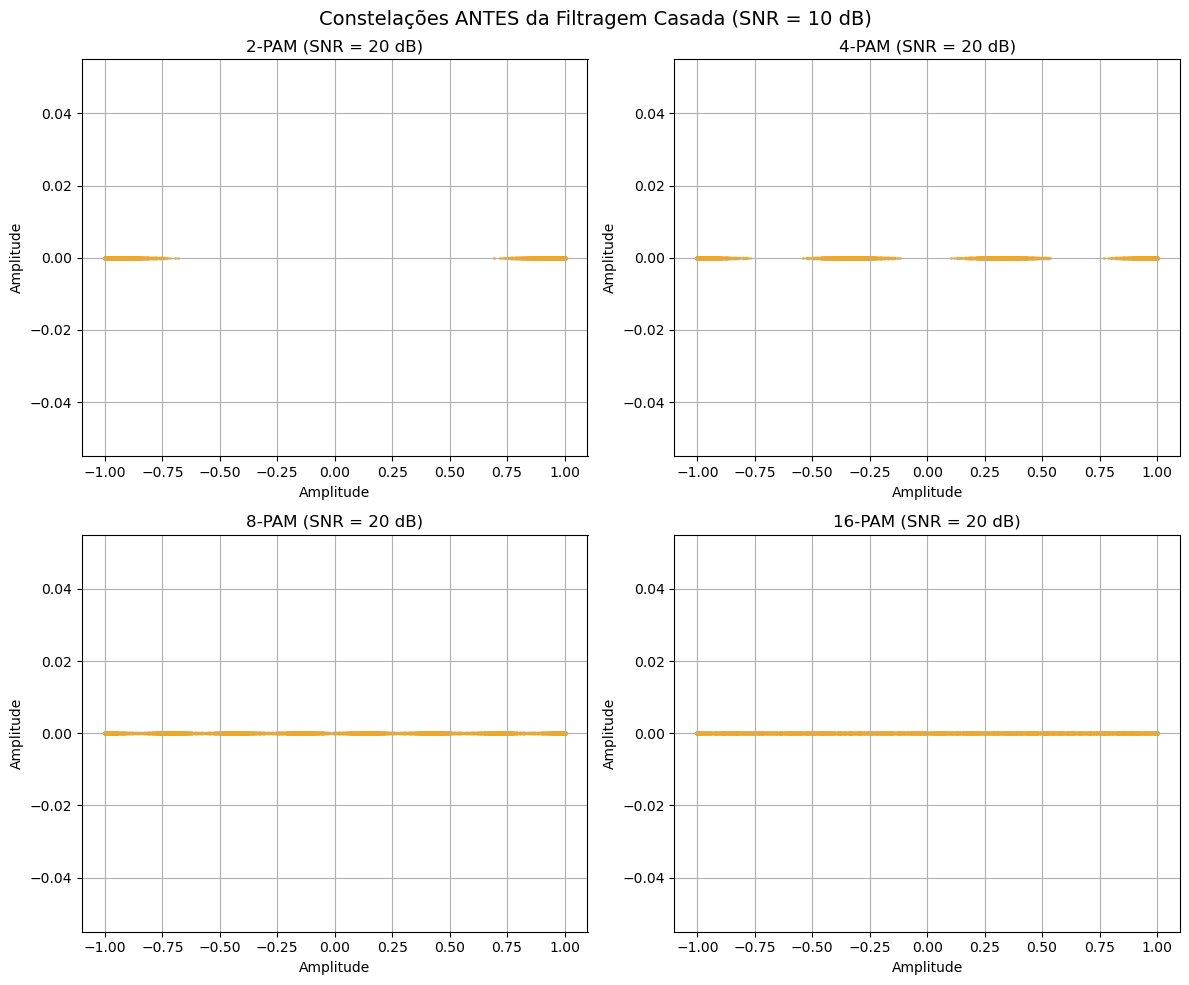

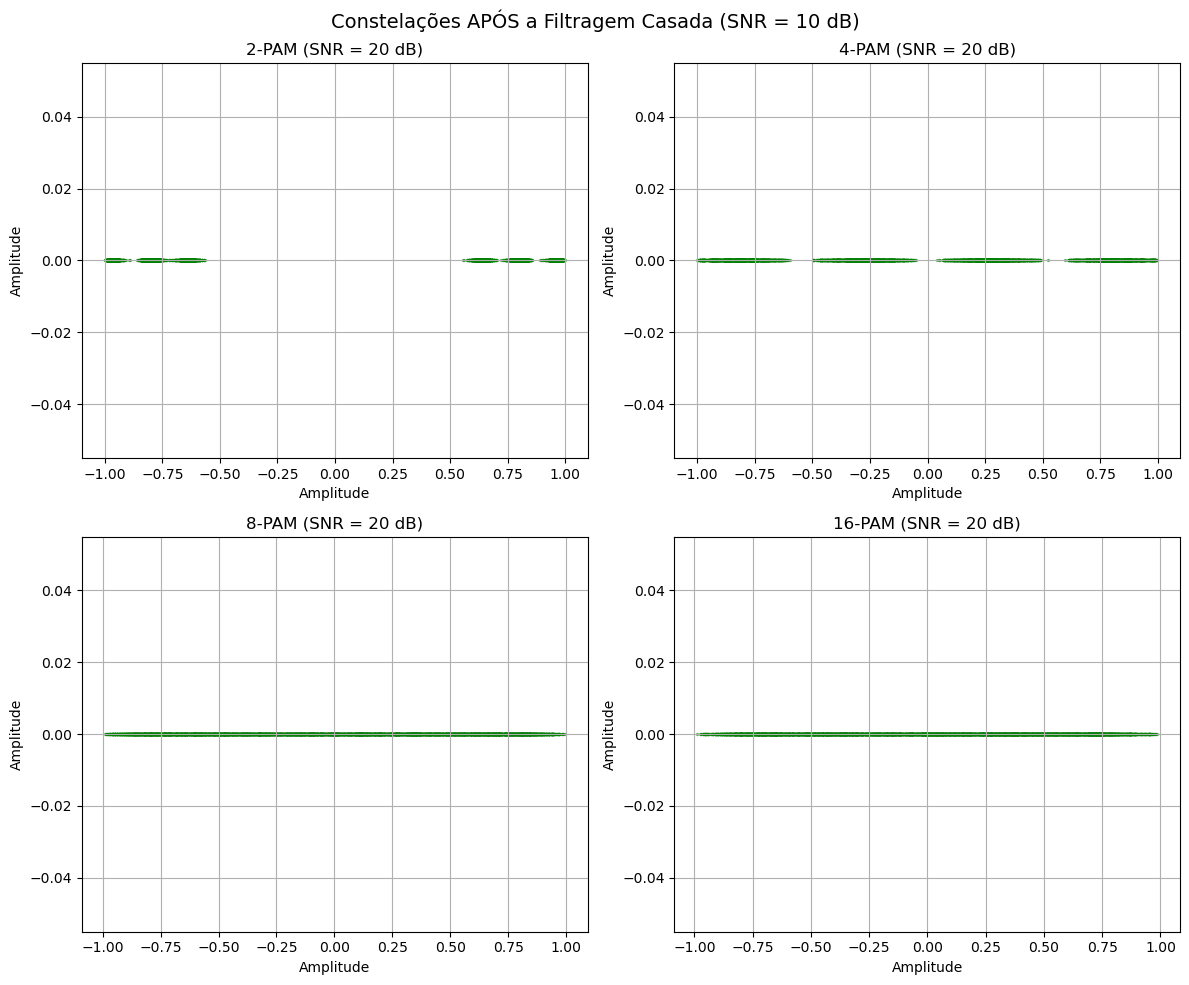

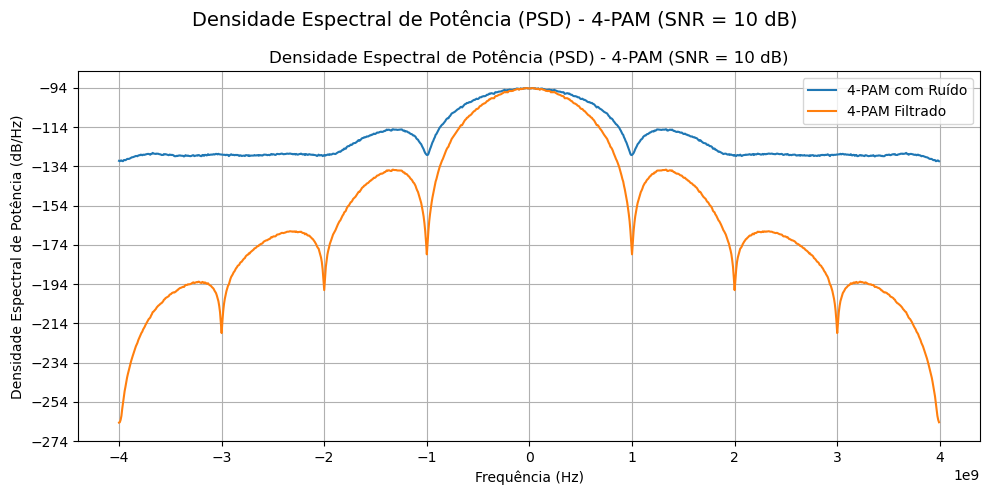

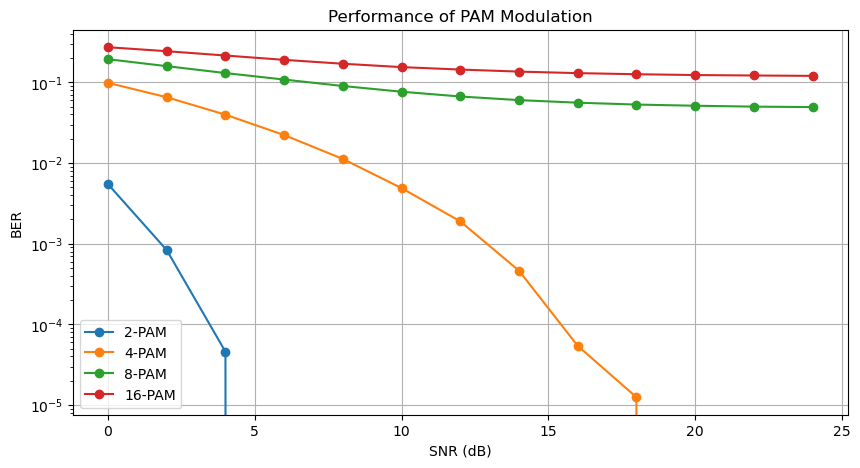

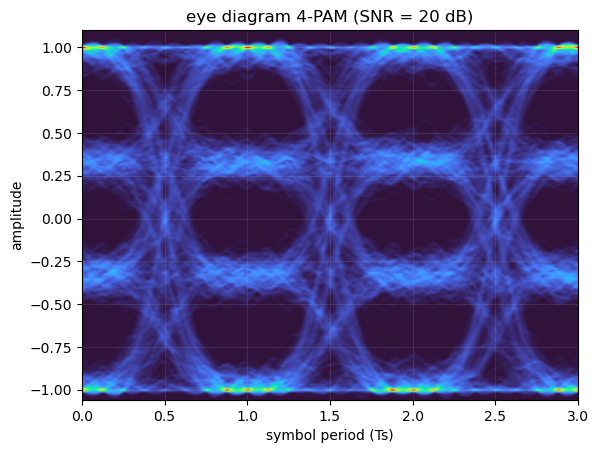

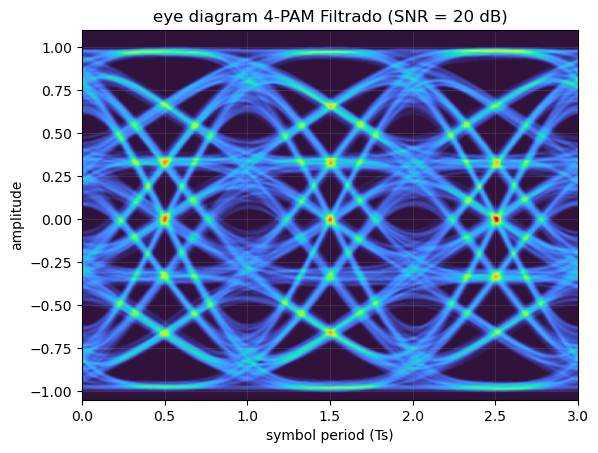

In [38]:
fig_rx, axes_rx = plt.subplots(2, 2, figsize=(12, 10))
fig_rx.suptitle('Constelações ANTES da Filtragem Casada (SNR = 10 dB)', fontsize=14)
axes_rx = axes_rx.flatten()

fig_filt, axes_filt = plt.subplots(2, 2, figsize=(12, 10))
fig_filt.suptitle('Constelações APÓS a Filtragem Casada (SNR = 10 dB)', fontsize=14)
axes_filt = axes_filt.flatten()

fig_psd, ax_psd = plt.subplots(figsize=(10, 5))
fig_psd.suptitle('Densidade Espectral de Potência (PSD) - 4-PAM (SNR = 10 dB)', fontsize=14)
SNR_dB = np.arange(0, 25, 2)

fig_ber, ax_ber = plt.subplots(figsize=(10, 5))
N = 1000

for i in range(len(M)):
    bers = []
    for snr in SNR_dB:
        sigRx = awgn(signalsTx[i], snr, Fs = Fs, B = Rs, complexNoise = False, seed = 42)
        sigRx = adc(sigRx, paramAdc)
        sigFilt = firFilter(pulse, sigRx)
        symbRx = decimate(sigFilt, paramDec)

        if snr == 20:
            # Plot da constelação ANTES da filtragem casada
            axes_rx[i].scatter(sigRx[N:N*SpS**2:SpS], np.zeros_like(sigRx[N:N*SpS**2:SpS]), alpha=0.5, s = 2, color = 'orange')
            axes_rx[i].set_title(f'{M[i]}-PAM (SNR = {snr} dB)')
            axes_rx[i].set_xlabel('Amplitude')
            axes_rx[i].set_ylabel('Amplitude')
            axes_rx[i].grid(True)

            # Plot da constelação APÓS a filtragem casada
            axes_filt[i].scatter(symbRx[N:N*SpS], np.zeros_like(symbRx[N:N*SpS]), alpha=0.5, s = 2, color = 'green')
            axes_filt[i].set_title(f'{M[i]}-PAM (SNR = {snr} dB)')
            axes_filt[i].set_xlabel('Amplitude')
            axes_filt[i].set_ylabel('Amplitude')
            axes_filt[i].grid(True)

            # Plot PSD 4-PAM
            if M[i] == 4:
                sigRx4 = sigRx.copy()
                sigFilt4 = sigFilt.copy()

        bers.append(fastBERcalc(symbRx, symbsTx[i], M[i], constType = 'pam')[0])

    
    ax_ber.semilogy(SNR_dB, bers, marker='o', label=f'{M[i]}-PAM')

fig_rx.tight_layout()
fig_filt.tight_layout()

ax_ber.set_xlabel('SNR (dB)')
ax_ber.set_ylabel('BER')
ax_ber.set_title('Performance of PAM Modulation')
ax_ber.legend()
ax_ber.grid(True)

ax_psd.psd(sigRx, NFFT = 1024, Fs = Fs, label='4-PAM com Ruído', sides = 'twosided')
ax_psd.psd(sigFilt, NFFT = 1024, Fs = Fs, label='4-PAM Filtrado', sides = 'twosided')
ax_psd.set_xlabel('Frequência (Hz)')
ax_psd.set_ylabel('Densidade Espectral de Potência (dB/Hz)')
ax_psd.set_title('Densidade Espectral de Potência (PSD) - 4-PAM (SNR = 10 dB)')
ax_psd.legend()
ax_psd.grid(True)
fig_psd.tight_layout()

# Plot diagramas de olho do sinal antes e depois da filtragem casada
eyediagram(sigRx4, Nsamples = len(sigRx4), SpS = SpS, ptype = 'fancy', plotlabel = f'4-PAM (SNR = 20 dB)')
eyediagram(sigFilt4, Nsamples = len(sigFilt4), SpS = SpS, ptype = 'fancy', plotlabel = f'4-PAM Filtrado (SNR = 20 dB)')

